In [146]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

In [77]:

h = '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Courses_Workshops/Water Resources Management/Q_paila'
q = pd.read_table(h, header=0 , names=['Date', 'Q_paila'], parse_dates=['Date'], index_col='Date')

/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_58919/4227506112.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_table(f, header=0 , names=['Date', 'Storage'], parse_dates=['Date'])
/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_58919/4227506112.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  prec = pd.read_table(g, header=0 , names=['Date', 'Greer', 'Eric'], parse_dates=['Date'])


In [79]:
q_monthly = q.resample('M').mean()
q_monthly['Q_paila'] = q_monthly['Q_paila'].interpolate(method='linear')


/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_58919/199165417.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  q_monthly = q.resample('M').mean()


<Axes: title={'center': 'Monthly Average Discharge at La Paila gage'}, xlabel='Date', ylabel='Streamflow (m3/s)'>

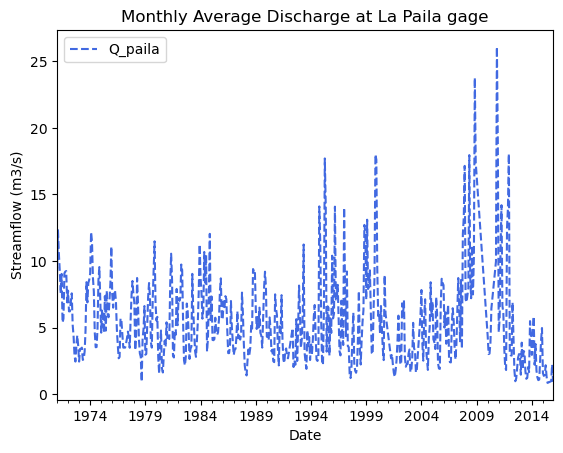

In [88]:
q_monthly.plot(title='Monthly Average Discharge at La Paila gage', ylabel='Streamflow (m3/s)', xlabel='Date', style='--', color='royalblue')

In [203]:
# moving average model using statsmodels
ma = 36
ma_model = sm.tsa.statespace.SARIMAX(q_monthly,
                                        order=(0, 0, ma),
                                        seasonal_order=(0, 0, 0, 0),
                                        enforce_stationarity=False,
                                        enforce_invertibility=False)
ma_results = ma_model.fit(disp=False)


/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [204]:
ma_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                Q_paila   No. Observations:                  540
Model:              SARIMAX(0, 0, 36)   Log Likelihood               -1195.145
Date:                Thu, 06 Nov 2025   AIC                           2464.290
Time:                        22:19:19   BIC                           2620.452
Sample:                    01-31-1971   HQIC                          2525.552
                         - 12-31-2015                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.8480      0.097      8.699      0.000       0.657       1.039
ma.L2          0.3985      0.053      7.462      0.000       0.294       0.503
ma.L3          0.3908      0.060      6.540      0.000       0.274       0.508
ma.L4          0.4413      0.073      6.078      0.000       0.299       0.584
ma.L5          0.3625      0.071      5.073      0.000       0.222       0.503
ma.L6          0.6011      0.082      7.342      0.000       0.441       0.762
ma.L7          0.3988      0.073      5.482      0.000       0.256       0.541
ma.L8          0.4125      0.080      5.155      0.000       0.256       0.569
ma.L9          0.2100      0.080      2.639      0.008       0.054       0.366
ma.L10         0.3375      0.083      4.075      0.000       0.175       0.500
ma.L11         0.4091      0.087      4.721      0.000       0.239       0.579
ma.L12         0.4537      0.080      5.704      0.000       0.298       0.610
ma.L13         0.5903      0.088      6.717      0.000       0.418       0.762
ma.L14         0.2582      0.082      3.161      0.002       0.098       0.418
ma.L15         0.3472      0.089      3.922      0.000       0.174       0.521
ma.L16         0.2563      0.090      2.838      0.005       0.079       0.433
ma.L17         0.3848      0.092      4.179      0.000       0.204       0.565
ma.L18         0.3333      0.088      3.776      0.000       0.160       0.506
ma.L19         0.3192      0.090      3.531      0.000       0.142       0.496
ma.L20         0.2252      0.104      2.173      0.030       0.022       0.428
ma.L21         0.2144      0.106      2.015      0.044       0.006       0.423
ma.L22         0.2976      0.102      2.919      0.004       0.098       0.497
ma.L23         0.3155      0.106      2.973      0.003       0.108       0.524
ma.L24         0.3860      0.101      3.808      0.000       0.187       0.585
ma.L25         0.2784      0.106      2.628      0.009       0.071       0.486
ma.L26         0.1467      0.103      1.428      0.153      -0.055       0.348
ma.L27         0.2030      0.104      1.958      0.050      -0.000       0.406
ma.L28         0.1894      0.106      1.793      0.073      -0.018       0.396
ma.L29         0.2158      0.099      2.186      0.029       0.022       0.409
ma.L30         0.0988      0.092      1.076      0.282      -0.081       0.279
ma.L31         0.0667      0.088      0.760      0.447      -0.105       0.239
ma.L32         0.0315      0.081      0.391      0.695      -0.126       0.189
ma.L33         0.0074      0.084      0.087      0.930      -0.158       0.173
ma.L34         0.0216      0.071      0.305      0.760      -0.117       0.160
ma.L35         0.1603      0.071      2.252      0.024       0.021       0.300
ma.L36         0.1503      0.058      2.612      0.009       0.038       0.263
sigma2         5.5150      0.589      9.370      0.000       4.361       6.669
=================================================================================

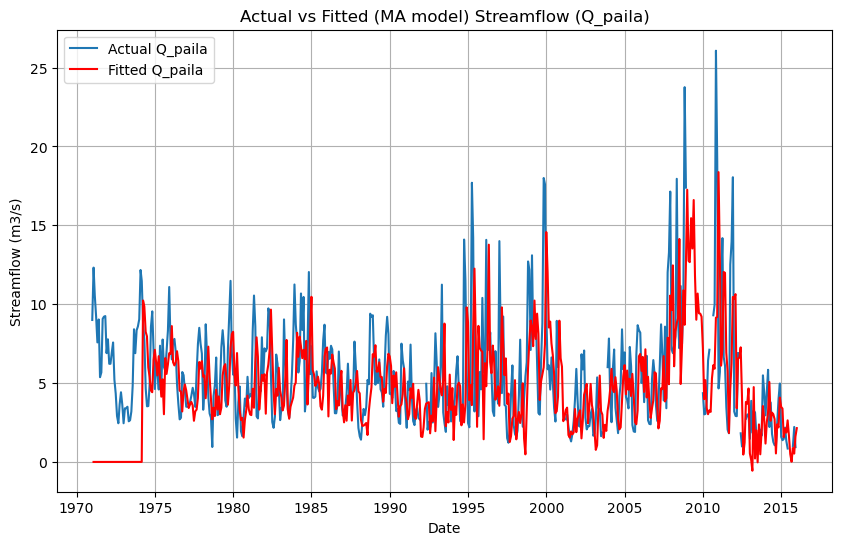

In [205]:
#rsults for ma model
plt.figure(figsize=(10, 6))
plt.plot(q, label='Actual Q_paila')
plt.plot(ma_results.fittedvalues, color='red', label='Fitted Q_paila')
plt.title('Actual vs Fitted (MA model) Streamflow (Q_paila)')
plt.xlabel('Date')
plt.ylabel('Streamflow (m3/s)')
plt.legend()
plt.grid()

In [206]:
# error metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = np.sqrt(mean_squared_error(q_monthly[ma:], ma_results.fittedvalues[ma:]))
mae = mean_absolute_error(q_monthly[ma:], ma_results.fittedvalues[ma:])
nash = 1 - (sum((q_monthly[ma:]['Q_paila'] - ma_results.fittedvalues[ma:])**2) / sum((q_monthly['Q_paila'][ma:] - q_monthly['Q_paila'][ma:].mean())**2))
print(f'Root Mean Squared Error (MA model): {mse}')
print(f'Mean Absolute Error (MA model): {mae}')
print(f'Nash-Sutcliffe Efficiency (MA model): {nash}')


Root Mean Squared Error (MA model): 2.668024380183242
Mean Absolute Error (MA model): 1.8393840086123432
Nash-Sutcliffe Efficiency (MA model): 0.41996917577010917


In [70]:
# grid search for best SARIMA parameters
import itertools
p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]
best_aic = float("inf")
best_params = None
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            model = sm.tsa.statespace.SARIMAX(q_monthly,
                                              order=param,
                                              seasonal_order=param_seasonal,
                                              enforce_stationarity=False,
                                              enforce_invertibility=False)
            results = model.fit(disp=False)
            if results.aic < best_aic:
                best_aic = results.aic
                best_params = (param, param_seasonal)
        except:
            continue
print(f'Best SARIMA parameters: {best_params} with AIC: {best_aic}')
# The best parameters found can be used to refit the model
model = sm.tsa.statespace.SARIMAX(q_monthly,
                                  order=best_params[0],
                                  seasonal_order=best_params[1],
                                  enforce_stationarity=False,
                                  enforce_invertibility=False)
results = model.fit(disp=False)


/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/

Best SARIMA parameters: ((1, 0, 2), (1, 1, 2, 12)) with AIC: 2348.310778018167


In [209]:
model = sm.tsa.statespace.SARIMAX(q_monthly,
                                  order=best_params[0],
                                  seasonal_order=best_params[1],
                                  enforce_stationarity=False,
                                  enforce_invertibility=False)
results = model.fit(disp=False)

Text(0.02, 0.95, 'Parameters: ((1, 0, 2), (1, 1, 2, 12))')

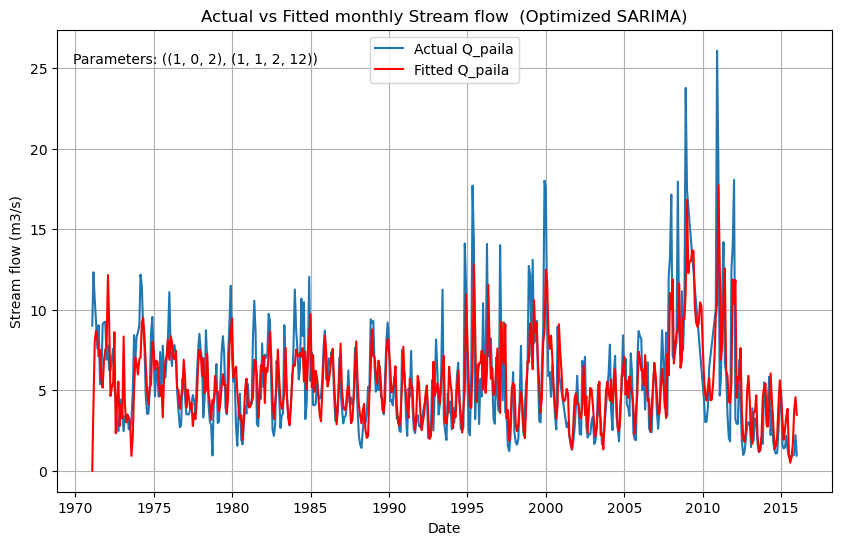

In [210]:
#plot fitted vs actual for q_monthloly
plt.figure(figsize=(10, 6))
plt.plot(q_monthly, label='Actual Q_paila')
plt.plot(results.fittedvalues, color='red', label='Fitted Q_paila')
plt.title('Actual vs Fitted monthly Stream flow  (Optimized SARIMA)')
plt.xlabel('Date')
plt.ylabel('Stream flow (m3/s)')
plt.legend()
plt.grid()
# show parameters
plt.text(0.02, 0.95, f'Parameters: {best_params}', transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top')


In [211]:
mse = np.sqrt(mean_squared_error(q_monthly, results.fittedvalues))
mae = mean_absolute_error(q_monthly, results.fittedvalues)
nash = 1 - (sum((q_monthly['Q_paila'] - results.fittedvalues) ** 2) / sum((q_monthly['Q_paila'] - q_monthly['Q_paila'].mean()) ** 2))
print(f'Root Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'Nash-Sutcliffe Efficiency: {nash}')

Root Mean Squared Error: 2.507835173120989
Mean Absolute Error: 1.7135524227413457
Nash-Sutcliffe Efficiency: 0.4735222268002952
